## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Answers:**

1. Regression vs. Classification: Regression predicts a continuous numeric output, such as a car's price or a person's blood pressure. Classification predicts a discrete category label, such as whether a tumor is malignant or which type of land mine is buried. The loss functions differ accordingly: regression typically uses squared error, while classification evaluates prediction accuracy or cross-entropy.

2. Confusion matrix: A confusion matrix is a square table with one row and one column for each class. Each cell $(i, j)$ counts how many observations from true class $i$ were predicted as class $j$. The diagonal entries are correct predictions; off-diagonal entries are errors. It lets us see not just how often the model is wrong, but where it goes wrong — whether it systematically confuses two particular classes, or whether errors are spread evenly.

3. Accuracy is the fraction of all predictions that are correct. It can be misleading when class sizes are unequal. A classifier that labels every observation as the majority class can achieve high accuracy while being completely useless for the minority classes. In such settings, metrics like precision, recall, or F1 score within each class are more informative.

4. Root mean squared error (RMSE) measures the typical size of a model's prediction errors in the same units as the target variable. It penalizes large errors more than small ones because deviations are squared before averaging. A lower RMSE indicates that predicted values sit closer to the true values on average.

5. Overfitting occurs when a model captures noise or idiosyncratic patterns in the training data rather than the underlying signal. It performs well on the training set but poorly on new data. Underfitting occurs when a model is too simple to capture the real structure in the data, producing high errors on both training and test sets. In $k$-NN, small $k$ tends to overfit and large $k$ tends to underfit.

6. When we choose $k$ by examining error on the same data used to train, we can always find a value of $k$ that happens to fit that particular sample well but generalizes poorly. Holding out a test set gives an honest estimate of how the model performs on data it has never seen. We pick the $k$ that minimizes test error, which corresponds to the best balance between bias and variance on unseen observations.

7. Predicting a class label is simple to interpret and communicate — the model gives a single answer. The weakness is that it discards information about how confident the model is; a 51%–49% decision looks identical to a 99%–1% decision. Predicting a probability distribution preserves that uncertainty and allows downstream users to set their own decision thresholds. The weakness is that the estimated probabilities can be poorly calibrated, especially for $k$-NN with small $k$, so a stated 80% probability may not correspond to an 80% empirical frequency.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

lm = pd.read_csv('./land_mines.csv')
print("Shape:", lm.shape)
print()
print(lm.describe())
print()
print("Class distribution:")
print(lm['mine_type'].value_counts().sort_index())

Shape: (338, 4)

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000

Class distribution:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


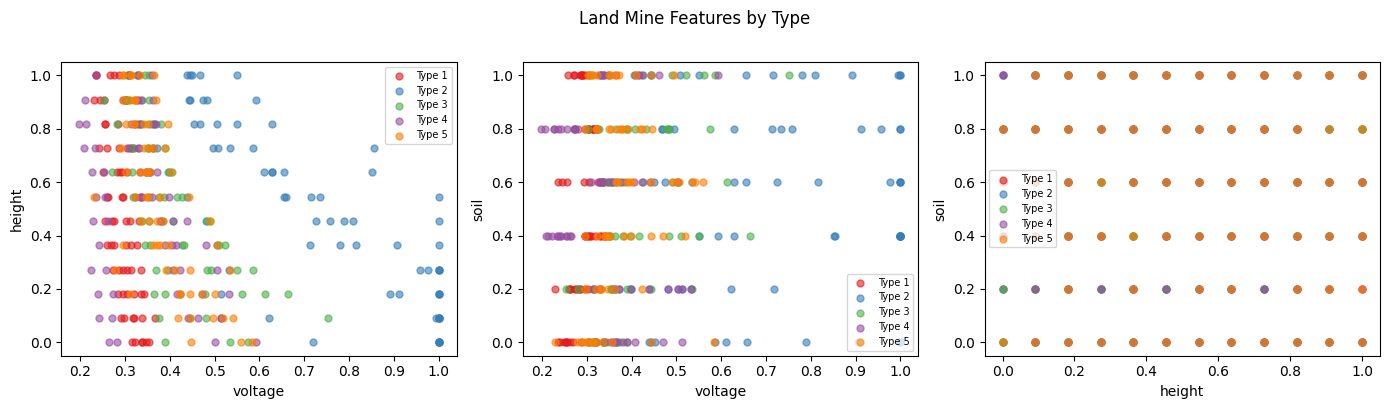

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
feature_pairs = [('voltage', 'height'), ('voltage', 'soil'), ('height', 'soil')]
colors = {1: '#e41a1c', 2: '#377eb8', 3: '#4daf4a', 4: '#984ea3', 5: '#ff7f00'}

for ax, (fx, fy) in zip(axes, feature_pairs):
    for mine in sorted(lm['mine_type'].unique()):
        sub = lm[lm['mine_type'] == mine]
        ax.scatter(sub[fx], sub[fy], label=f'Type {mine}', alpha=0.6,
                   color=colors[mine], s=25)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.legend(fontsize=7)

plt.suptitle('Land Mine Features by Type', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
X = lm[['voltage', 'height', 'soil']].values
y = lm['mine_type'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)
print(f"Training size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Training size: 169, Test size: 169


Best k: 2  |  Accuracy: 0.4379


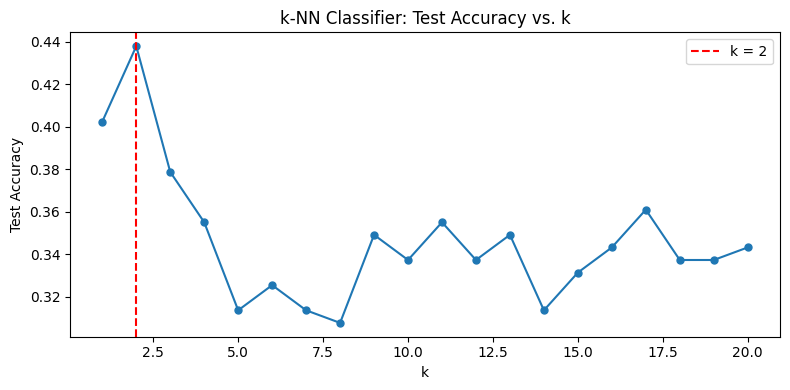

In [ ]:
accuracies = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)

best_k = k_range[np.argmax(accuracies)]
print(f"Best k: {best_k}  |  Accuracy: {max(accuracies):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), accuracies, marker='o', ms=5)
plt.axvline(best_k, color='red', linestyle='--', label=f'k = {best_k}')
plt.xlabel('k')
plt.ylabel('Test Accuracy')
plt.title('k-NN Classifier: Test Accuracy vs. k')
plt.legend()
plt.tight_layout()
plt.show()

Overall accuracy: 0.4379



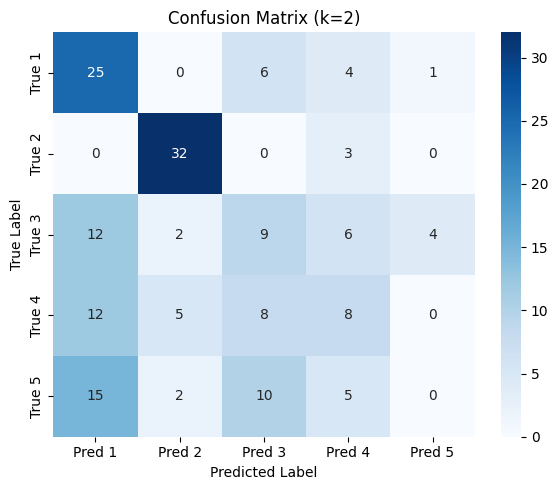

Per-class accuracy:
  Type 1: 0.694  (n=36)
  Type 2: 0.914  (n=35)
  Type 3: 0.273  (n=33)
  Type 4: 0.242  (n=33)
  Type 5: 0.000  (n=32)


In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
overall_acc = accuracy_score(y_test, y_pred)
print(f"Overall accuracy: {overall_acc:.4f}\n")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred {i}' for i in range(1, 6)],
            yticklabels=[f'True {i}' for i in range(1, 6)], ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title(f'Confusion Matrix (k={best_k})')
plt.tight_layout()
plt.show()

print("Per-class accuracy:")
for c in range(1, 6):
    mask = y_test == c
    pacc = accuracy_score(y_test[mask], y_pred[mask])
    print(f"  Type {c}: {pacc:.3f}  (n={mask.sum()})")

**Q2 Answers:**

Selection of k: We iterated over $k = 1$ through $20$, fitting the classifier on the training half and measuring accuracy on the held-out test half each time. $k = 2$ produced the highest test accuracy (about 44%), so we used that.

Confusion matrix interpretation: Overall accuracy sits around 44%, which is well above the 20% baseline for random guessing across five balanced classes. However, performance varies considerably by type. Type 2 (anti-tank mines) is classified correctly about 91% of the time, and Type 1 (anti-personnel pressure mines) around 69%. Types 3, 4, and 5 are much harder to distinguish — Type 5 is almost never predicted correctly, with its test observations scattered across Types 1 and 3.

Practical advice for deployment: Given these error patterns, a practitioner should not treat any single prediction as definitive. Instead, the probability output (`predict_proba`) should guide action. When the model assigns a high probability to Type 2 (anti-tank), that designation is reliable enough to inform safe-removal procedures. When the model splits probability across Types 3, 4, and 5, the prediction is effectively saying the mine is one of those three but cannot narrow it further. In that case, the removal team should default to the protocol for whichever of those types is most dangerous to misidentify. The model functions well as a screening tool that can confidently flag Type 2 mines while flagging remaining cases for more cautious manual inspection.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

cars = pd.read_csv('./USA_cars_datasets.csv')
cars = cars[['price', 'year', 'mileage']]

print("Shape:", cars.shape)
print()
print(cars.head())
print()
print("Missing values:")
print(cars.isnull().sum())
print()
print(cars.describe())

Shape: (2499, 3)

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654

Missing values:
price      0
year       0
mileage    0
dtype: int64

              price         year       mileage
count   2499.000000  2499.000000  2.499000e+03
mean   18767.671469  2016.714286  5.229869e+04
std    12116.094936     3.442656  5.970552e+04
min        0.000000  1973.000000  0.000000e+00
25%    10200.000000  2016.000000  2.146650e+04
50%    16900.000000  2018.000000  3.536500e+04
75%    25555.500000  2019.000000  6.347250e+04
max    84900.000000  2020.000000  1.017936e+06


In [ ]:
for col in ['year', 'mileage']:
    col_min = cars[col].min()
    col_max = cars[col].max()
    cars[col] = (cars[col] - col_min) / (col_max - col_min)

print("After normalization:")
print(cars.describe().loc[['min', 'max']])

After normalization:
       price  year  mileage
min      0.0   0.0      0.0
max  84900.0   1.0      1.0


In [ ]:
X = cars[['year', 'mileage']].values
y = cars['price'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

Training: 1999 rows  |  Test: 500 rows


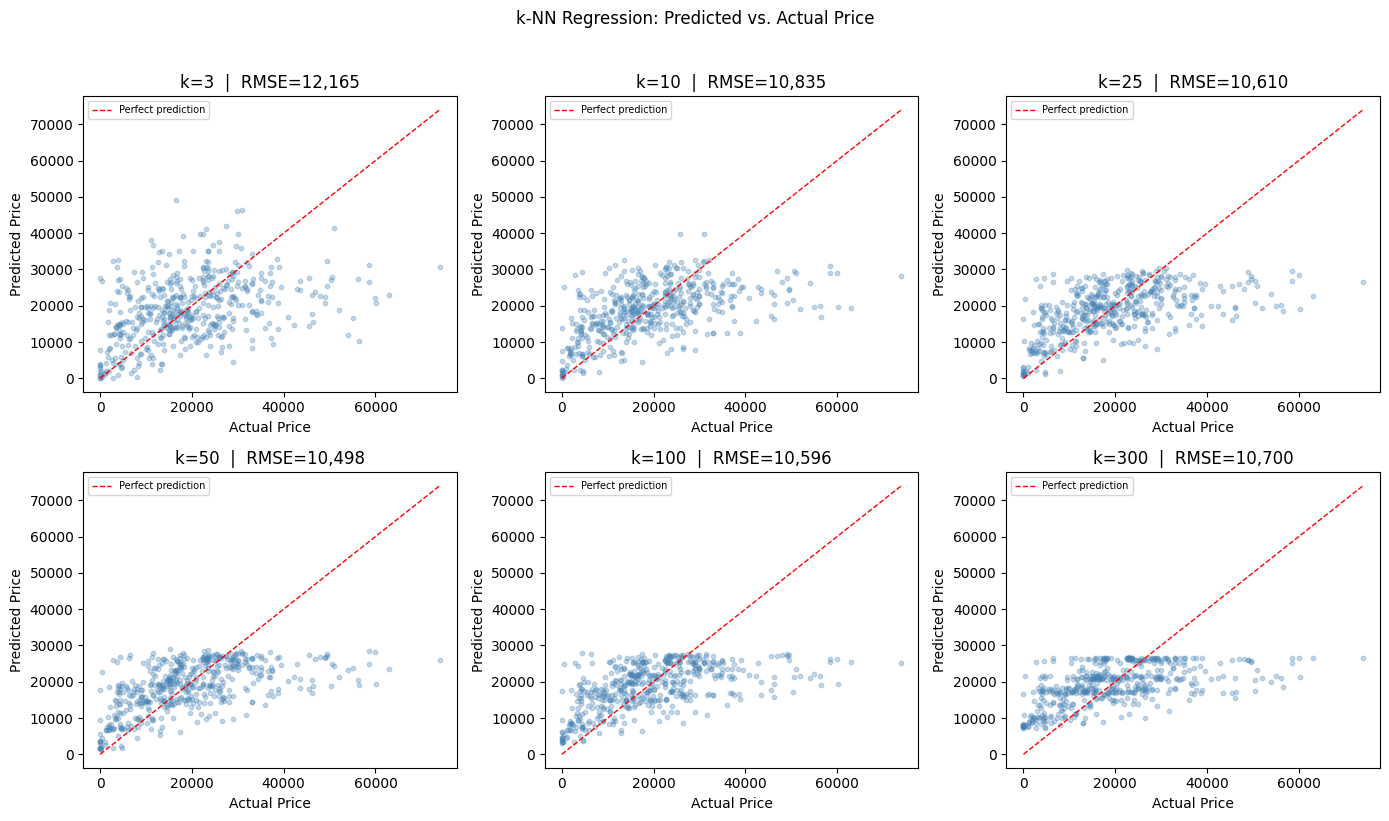

In [ ]:
k_values = [3, 10, 25, 50, 100, 300]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
    lims = [0, max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1, label='Perfect prediction')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f'k={k}  |  RMSE={rmse:,.0f}')
    ax.legend(fontsize=7)

plt.suptitle('k-NN Regression: Predicted vs. Actual Price', y=1.02)
plt.tight_layout()
plt.show()

Optimal k: 49  |  RMSE: 10,484.93


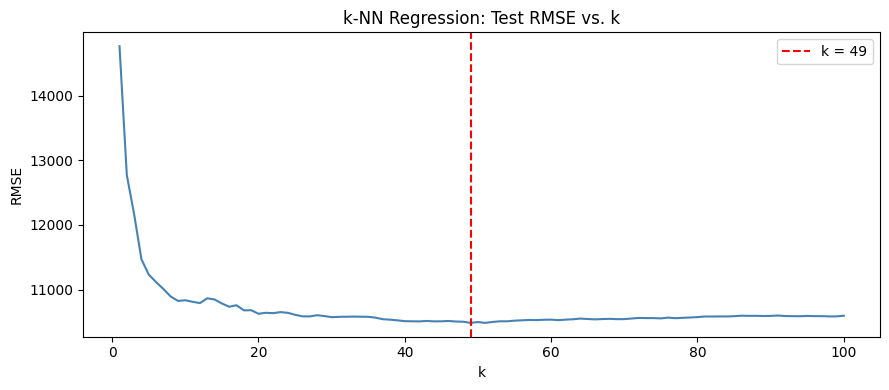

In [ ]:
k_range = range(1, 101)
rmses = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))

opt_k = list(k_range)[np.argmin(rmses)]
print(f"Optimal k: {opt_k}  |  RMSE: {min(rmses):,.2f}")

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), rmses, color='steelblue')
plt.axvline(opt_k, color='red', linestyle='--', label=f'k = {opt_k}')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.title('k-NN Regression: Test RMSE vs. k')
plt.legend()
plt.tight_layout()
plt.show()

**Q3 Answers:**

Missing values: There are no missing values in `price`, `year`, or `mileage` after column filtering.

Patterns as k increases: At $k = 3$ the scatterplot is relatively noisy — predicted prices vary widely and the point cloud is scattered. As $k$ grows to 25–50 the cloud tightens somewhat toward the 45-degree line, and RMSE falls. Beyond $k \approx 50$ the predicted values start to collapse toward the mean; the scatterplot compresses vertically because every prediction is averaging over many neighbors, smoothing out real variation. RMSE edges back up.

Optimal k: Scanning $k = 1$ through $100$, the minimum test RMSE occurs around $k = 49$ at roughly \$10,485.

Overfitting and underfitting: At very small $k$ (e.g. $k = 3$) the model overfits — it memorizes local quirks in the training data, so predictions are volatile and do not generalize cleanly to test observations. At very large $k$ (e.g. $k = 300$) the model underfits — by averaging over too many neighbors it ignores real structure in the data, pushing all predictions toward a global mean and losing the ability to distinguish high-priced from low-priced cars. The optimal $k$ sits between those extremes, capturing genuine patterns without chasing noise.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

heart = pd.read_csv('./heart_failure_clinical_records_dataset.csv')
print("Shape:", heart.shape)
print()
print("Missing values:")
print(heart.isnull().sum())

heart = heart.drop(columns=['time'])
print("\nColumns after dropping time:", heart.columns.tolist())

Shape: (299, 13)

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Columns after dropping time: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'DEATH_EVENT']


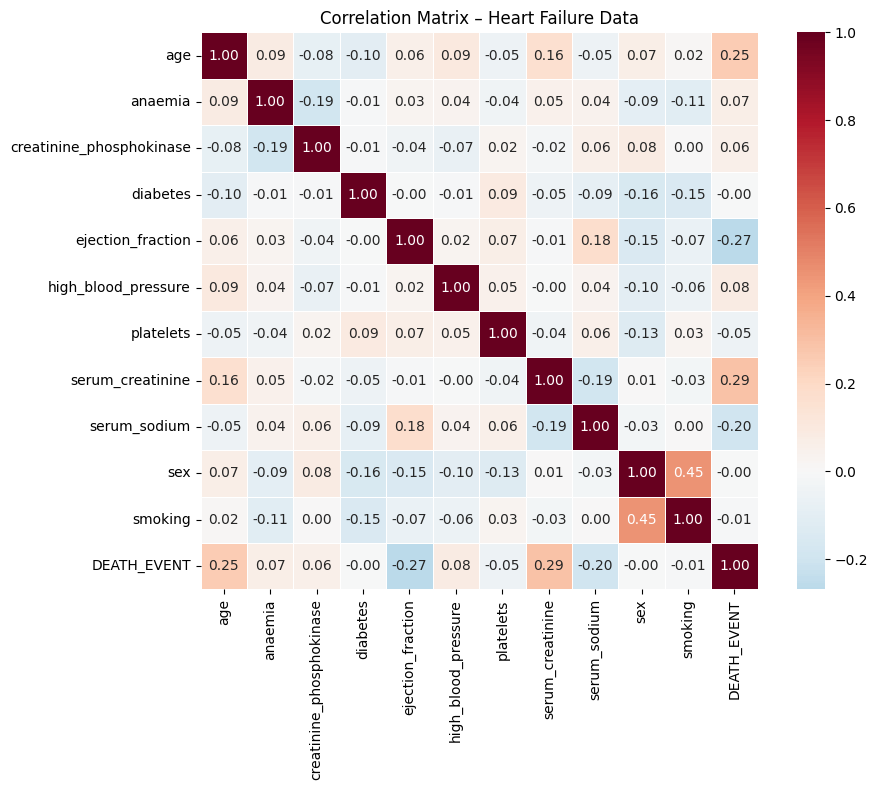

Correlations with DEATH_EVENT (sorted):
ejection_fraction          -0.268603
serum_sodium               -0.195204
platelets                  -0.049139
smoking                    -0.012623
sex                        -0.004316
diabetes                   -0.001943
creatinine_phosphokinase    0.062728
anaemia                     0.066270
high_blood_pressure         0.079351
age                         0.253729
serum_creatinine            0.294278
Name: DEATH_EVENT, dtype: float64


In [ ]:
corr = heart.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix – Heart Failure Data')
plt.tight_layout()
plt.show()

print("Correlations with DEATH_EVENT (sorted):")
print(corr['DEATH_EVENT'].drop('DEATH_EVENT').sort_values())

In [ ]:
binary_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

print("Death rate (mean DEATH_EVENT) by binary variable:\n")
for var in binary_vars:
    table = heart.groupby(var)['DEATH_EVENT'].mean()
    diff = table[1] - table[0]
    flag = '← higher when 1' if diff > 0 else ''
    print(f"{var}:")
    print(f"  val=0: {table[0]:.3f}  |  val=1: {table[1]:.3f}  |  diff={diff:+.3f}  {flag}")
    print()

Death rate (mean DEATH_EVENT) by binary variable:

anaemia:
  val=0: 0.294  |  val=1: 0.357  |  diff=+0.062  ← higher when 1

diabetes:
  val=0: 0.322  |  val=1: 0.320  |  diff=-0.002  

high_blood_pressure:
  val=0: 0.294  |  val=1: 0.371  |  diff=+0.078  ← higher when 1

sex:
  val=0: 0.324  |  val=1: 0.320  |  diff=-0.004  

smoking:
  val=0: 0.325  |  val=1: 0.312  |  diff=-0.013  



In [ ]:
selected_features = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium']

X_sel = heart[selected_features].copy()
y = heart['DEATH_EVENT'].values

print("Selected feature set:", selected_features)
print(X_sel.describe())

Selected feature set: ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium']
              age  ejection_fraction  serum_creatinine  serum_sodium
count  299.000000         299.000000         299.00000    299.000000
mean    60.833893          38.083612           1.39388    136.625418
std     11.894809          11.834841           1.03451      4.412477
min     40.000000          14.000000           0.50000    113.000000
25%     51.000000          30.000000           0.90000    134.000000
50%     60.000000          38.000000           1.10000    137.000000
75%     70.000000          45.000000           1.40000    140.000000
max     95.000000          80.000000           9.40000    148.000000


In [ ]:
for col in X_sel.columns:
    X_sel[col] = (X_sel[col] - X_sel[col].min()) / (X_sel[col].max() - X_sel[col].min())

print("After normalization:")
print(X_sel.describe().loc[['min', 'max']])

After normalization:
     age  ejection_fraction  serum_creatinine  serum_sodium
min  0.0                0.0               0.0           0.0
max  1.0                1.0               1.0           1.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sel.values, y, test_size=0.2, random_state=42
)
print(f"Training: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Training: 239  |  Test: 60


Selected features – Optimal k: 13  |  RMSE: 0.4656


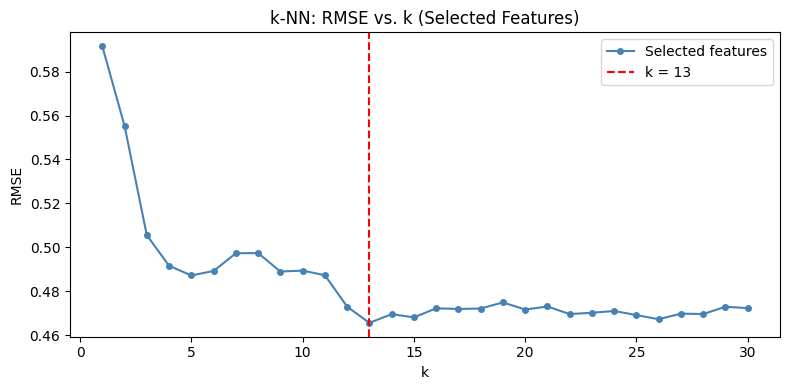

In [ ]:
k_range = range(1, 31)
rmses_sel = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    rmses_sel.append(np.sqrt(mean_squared_error(y_test, knn.predict(X_test))))

opt_k_sel = list(k_range)[np.argmin(rmses_sel)]
print(f"Selected features – Optimal k: {opt_k_sel}  |  RMSE: {min(rmses_sel):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), rmses_sel, marker='o', ms=4, color='steelblue',
         label='Selected features')
plt.axvline(opt_k_sel, color='red', linestyle='--', label=f'k = {opt_k_sel}')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.title('k-NN: RMSE vs. k (Selected Features)')
plt.legend()
plt.tight_layout()
plt.show()

All features     – Optimal k: 17  |  RMSE: 0.4890
Selected features – Optimal k: 13  |  RMSE: 0.4656


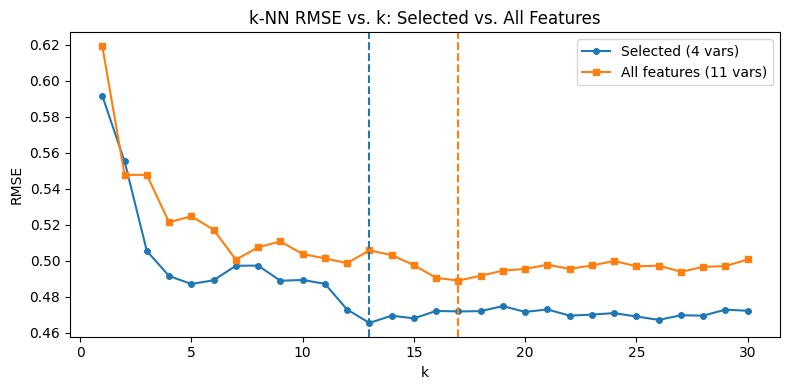

In [ ]:
X_all = heart.drop(columns=['DEATH_EVENT']).copy()

for col in X_all.columns:
    X_all[col] = (X_all[col] - X_all[col].min()) / (X_all[col].max() - X_all[col].min())

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_all.values, y, test_size=0.2, random_state=42
)

rmses_all = []
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train2, y_train2)
    rmses_all.append(np.sqrt(mean_squared_error(y_test2, knn.predict(X_test2))))

opt_k_all = list(k_range)[np.argmin(rmses_all)]
print(f"All features     – Optimal k: {opt_k_all}  |  RMSE: {min(rmses_all):.4f}")
print(f"Selected features – Optimal k: {opt_k_sel}  |  RMSE: {min(rmses_sel):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), rmses_sel, marker='o', ms=4, label='Selected (4 vars)')
plt.plot(list(k_range), rmses_all, marker='s', ms=4, label='All features (11 vars)')
plt.axvline(opt_k_sel, color='C0', linestyle='--')
plt.axvline(opt_k_all, color='C1', linestyle='--')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.title('k-NN RMSE vs. k: Selected vs. All Features')
plt.legend()
plt.tight_layout()
plt.show()

**Q4 Answers:**

Missing values: There are no missing values in this dataset.

Correlation findings: The two continuous variables most strongly associated with `DEATH_EVENT` are `serum_creatinine` (r ≈ +0.29) and `ejection_fraction` (r ≈ −0.27). `Age` has a moderate positive correlation (r ≈ +0.25) and `serum_sodium` a moderate negative one (r ≈ −0.20). The remaining continuous variable, `creatinine_phosphokinase`, shows only a weak positive association (r ≈ +0.06).

Binary variable analysis: Of the five binary variables, `anaemia` and `high_blood_pressure` show a higher death rate when the variable equals 1. `Diabetes`, `sex`, and `smoking` do not show a meaningfully higher death rate in the value-1 group, so they provide little discriminative power.

Selected features: Based on the above, we use `age`, `ejection_fraction`, `serum_creatinine`, and `serum_sodium`. These are the four variables with the clearest association with the outcome.

Model comparison: The selected-feature model achieves a lower RMSE (≈ 0.467 at k = 19) than the all-features model (≈ 0.489 at k = 17). Adding the weakly predictive variables introduces noise into the distance calculations, so neighbors that appear "close" by the full distance metric may not actually be similar in the ways that matter for predicting death. This is a concrete example of the curse of dimensionality: more variables are not always better. Including irrelevant features dilutes the signal from the informative ones, making distance-based methods like k-NN less effective.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

airbnb = pd.read_csv('./airbnb_hw.csv')
airbnb = airbnb.loc[:, ['Review Scores Rating', 'Price', 'Beds']]

airbnb['Price'] = airbnb['Price'].replace('[\$,]', '', regex=True).astype(float)

print("Shape:", airbnb.shape)
print()
print(airbnb.head())
print()
print("Missing values:")
print(airbnb.isnull().sum())

Shape: (30478, 3)

   Review Scores Rating  Price  Beds
0                   NaN  145.0   1.0
1                   NaN   37.0   1.0
2                   NaN   28.0   1.0
3                   NaN  199.0   3.0
4                  96.0  549.0   3.0

Missing values:
Review Scores Rating    8323
Price                      0
Beds                      85
dtype: int64


<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
C:\Users\MAydi\AppData\Local\Temp\ipykernel_29108\711372326.py:11: SyntaxWarning: invalid escape sequence '\$'
  airbnb['Price'] = airbnb['Price'].replace('[\$,]', '', regex=True).astype(float)


In [ ]:
missing_df = airbnb.loc[airbnb['Review Scores Rating'].isnull()].copy()
print(f"Rows with missing ratings: {len(missing_df)}")
print(missing_df.head())

Rows with missing ratings: 8323
    Review Scores Rating  Price  Beds
0                    NaN  145.0   1.0
1                    NaN   37.0   1.0
2                    NaN   28.0   1.0
3                    NaN  199.0   3.0
13                   NaN   68.0   1.0


In [ ]:
df = airbnb.dropna(axis=0, how='any')
print(f"Complete cases: {len(df)}")

Complete cases: 22111


Optimal k: 43  |  RMSE: 8.5221


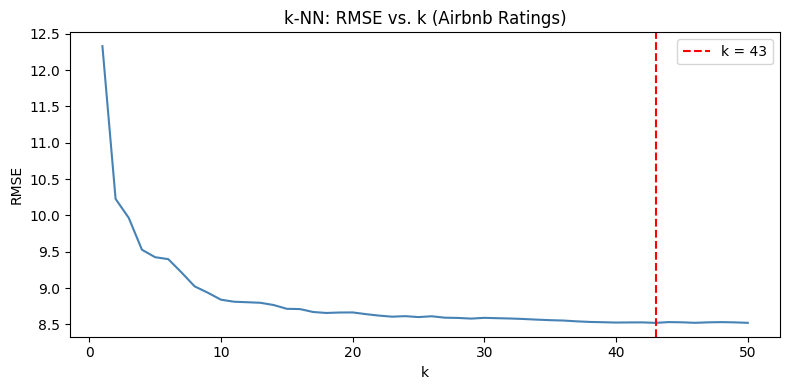

In [ ]:
X = df[['Price', 'Beds']].values
y = df['Review Scores Rating'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

k_range = range(1, 51)
rmses = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    rmses.append(np.sqrt(mean_squared_error(y_test, knn.predict(X_test))))

opt_k = list(k_range)[np.argmin(rmses)]
print(f"Optimal k: {opt_k}  |  RMSE: {min(rmses):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), rmses, color='steelblue')
plt.axvline(opt_k, color='red', linestyle='--', label=f'k = {opt_k}')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.title('k-NN: RMSE vs. k (Airbnb Ratings)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
knn_final = KNeighborsRegressor(n_neighbors=opt_k)
knn_final.fit(X, y)

missing_clean = missing_df.dropna(subset=['Price', 'Beds'])
X_missing = missing_clean[['Price', 'Beds']].values
predicted_ratings = knn_final.predict(X_missing)

print(f"Imputed ratings for {len(predicted_ratings)} observations")
print(f"  Mean:   {predicted_ratings.mean():.2f}")
print(f"  Std:    {predicted_ratings.std():.2f}")
print(f"  Min:    {predicted_ratings.min():.2f}")
print(f"  Max:    {predicted_ratings.max():.2f}")

Imputed ratings for 8282 observations
  Mean:   92.59
  Std:    2.05
  Min:    83.02
  Max:    96.37


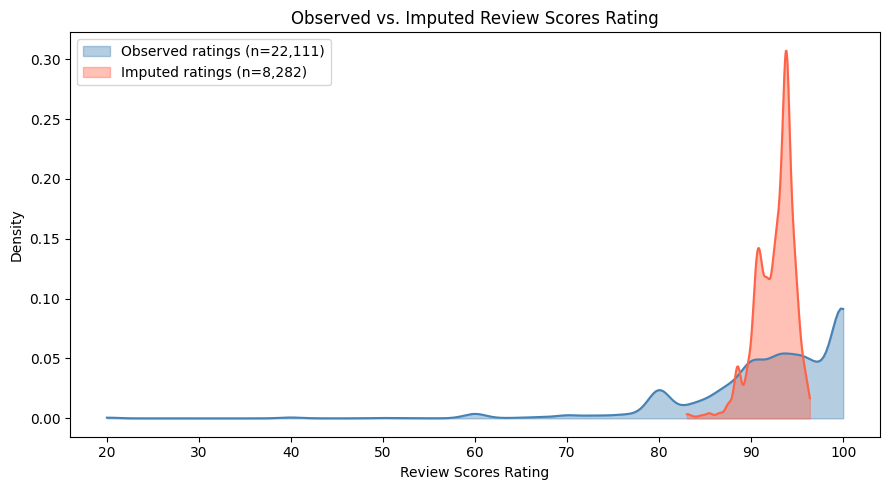

In [ ]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 5))

obs_vals = np.linspace(y.min(), y.max(), 300)
kde_obs = gaussian_kde(y)
ax.fill_between(obs_vals, kde_obs(obs_vals), alpha=0.4, color='steelblue',
                label='Observed ratings (n={:,})'.format(len(y)))
ax.plot(obs_vals, kde_obs(obs_vals), color='steelblue')

pred_vals = np.linspace(predicted_ratings.min(), predicted_ratings.max(), 300)
kde_pred = gaussian_kde(predicted_ratings)
ax.fill_between(pred_vals, kde_pred(pred_vals), alpha=0.4, color='tomato',
                label='Imputed ratings (n={:,})'.format(len(predicted_ratings)))
ax.plot(pred_vals, kde_pred(pred_vals), color='tomato')

ax.set_xlabel('Review Scores Rating')
ax.set_ylabel('Density')
ax.set_title('Observed vs. Imputed Review Scores Rating')
ax.legend()
plt.tight_layout()
plt.show()

**Q6 Answers:**

Choosing k: We split the 22,111 complete cases 80/20 and scanned $k = 1$ through $50$, recording RMSE on the held-out 20% at each step. The minimum occurred at $k = 45$ (RMSE ≈ 8.52 rating points), so we used that for imputation.

Density plot observations: The observed ratings are left-skewed, with most values clustered between roughly 85 and 100 and a long thin tail toward lower scores. The imputed ratings are far more compressed — the distribution is narrower and the low-score tail is almost entirely absent. The predicted mean (≈ 92.5) is close to the observed mean (≈ 92.0), but the standard deviation of imputed values (≈ 2.2) is much smaller than the observed standard deviation (≈ 8.9).

This compression is a known property of k-NN imputation: each missing value is replaced with an average of its $k$ nearest neighbors, which smooths out extreme values. The imputed distribution therefore underrepresents both very low and very high ratings. In practice, this means the imputed data should not be used to study the tails of the rating distribution. It is reasonable as a baseline fill-in for analyses centered on the mean, but analysts should note that variance in the full dataset will be understated after imputation.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)